## **Evolutionary Computation Methods in Image Processing**

### **Generative Art and Image Reconstruction with an evolution strategy and (1+1) hill-climber**

Initialized:
Target shape : (128, 128, 3)
Start tris   : 15 -> growing to 150
Initial MSE: 15246.806
Gen      0 | tris =  15 | MSE = 15246.81


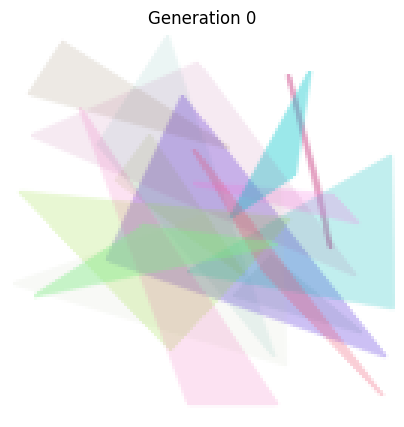

Gen   5000 | tris =  18 | MSE = 968.59


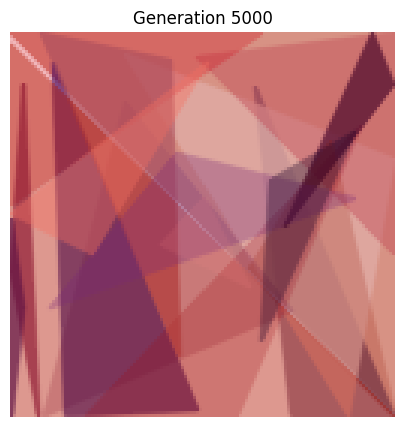

Gen  10000 | tris =  21 | MSE = 819.78


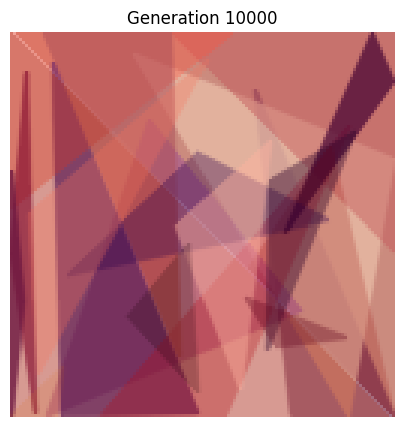

Gen  15000 | tris =  25 | MSE = 752.21


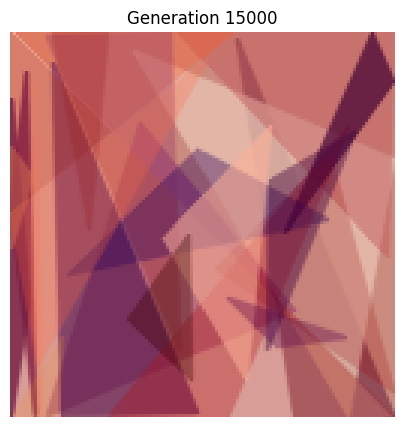

Gen  20000 | tris =  28 | MSE = 726.30


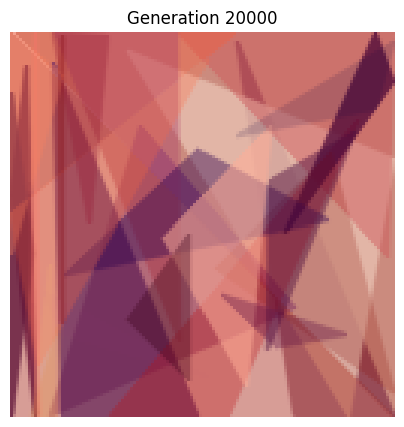

Gen  25000 | tris =  31 | MSE = 691.34


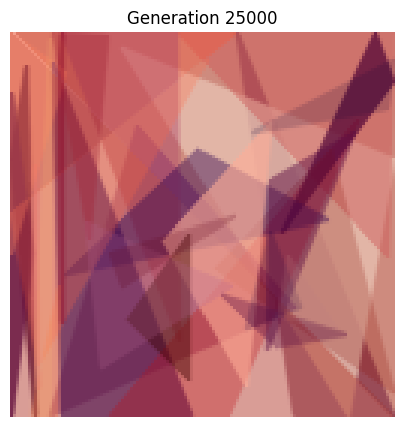

Gen  30000 | tris =  35 | MSE = 657.57


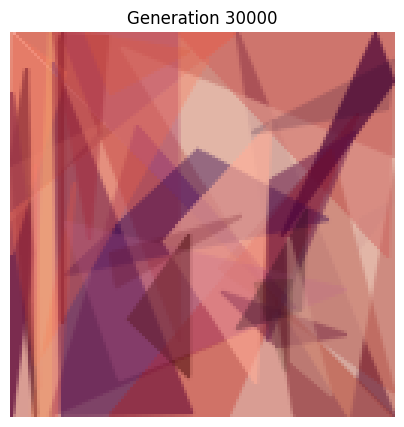

Gen  35000 | tris =  38 | MSE = 629.17


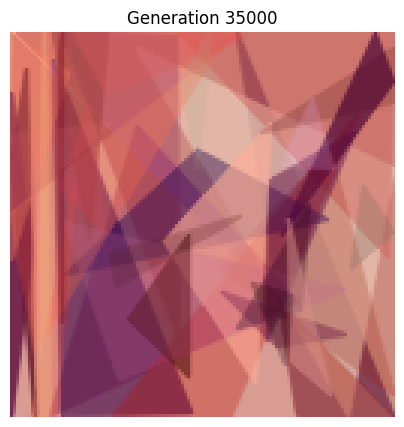

Gen  40000 | tris =  41 | MSE = 587.31


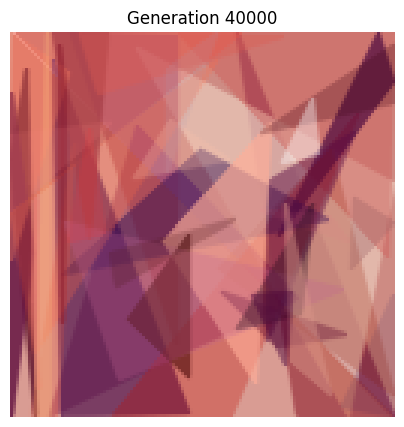

Gen  45000 | tris =  45 | MSE = 540.42


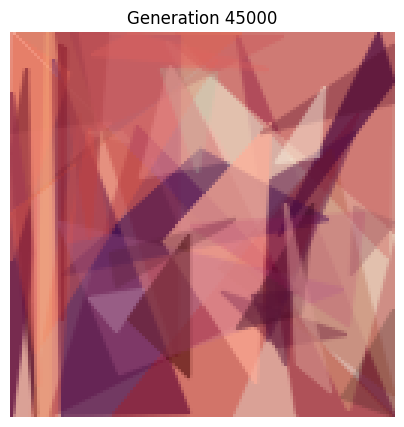

Gen  50000 | tris =  48 | MSE = 509.10


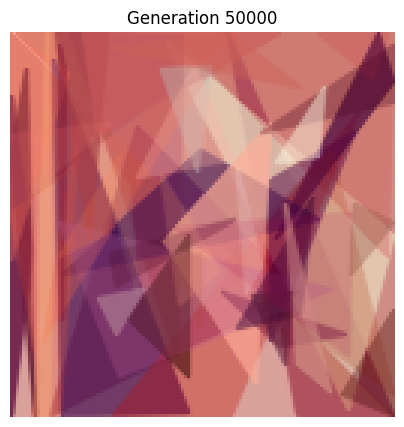

Gen  55000 | tris =  51 | MSE = 482.39


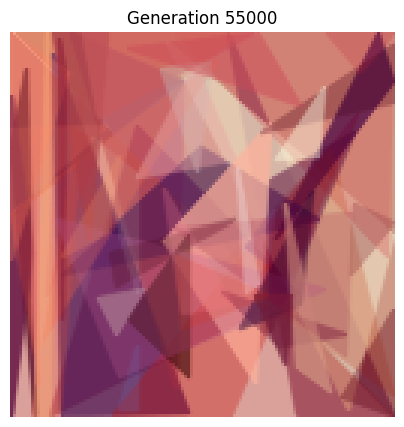

Gen  60000 | tris =  55 | MSE = 452.72


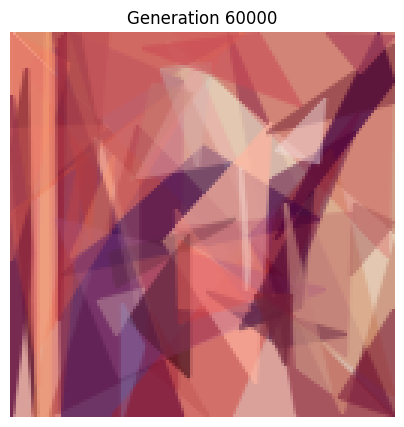

Gen  65000 | tris =  58 | MSE = 436.93


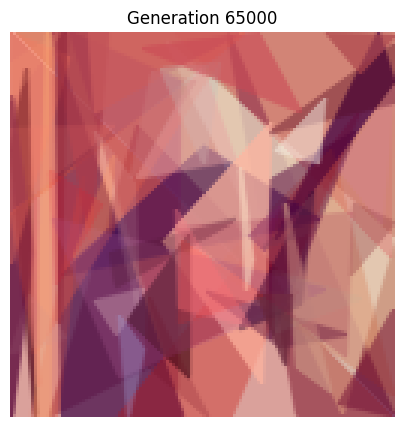

Gen  70000 | tris =  61 | MSE = 420.53


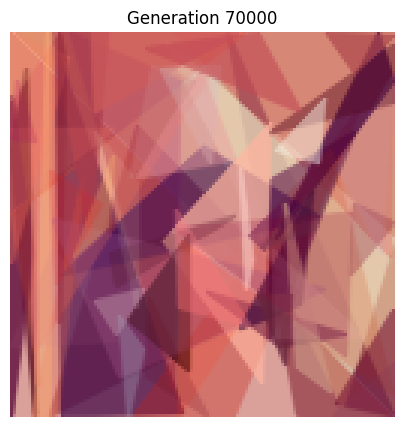

Gen  75000 | tris =  65 | MSE = 402.80


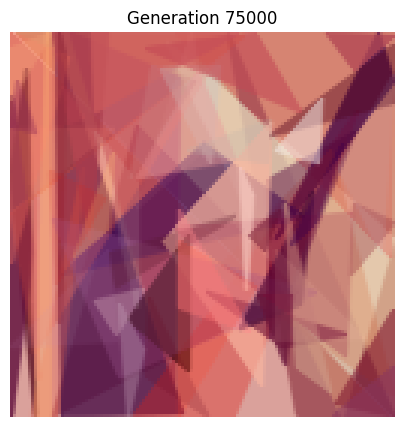

Gen  80000 | tris =  68 | MSE = 383.92


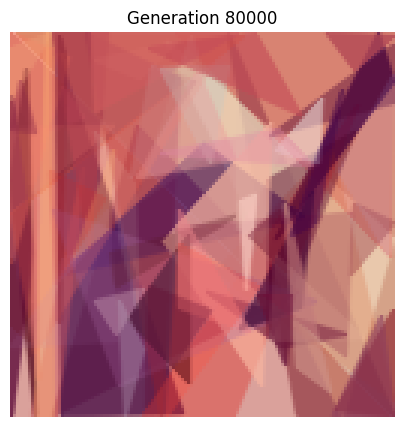

Gen  85000 | tris =  71 | MSE = 368.99


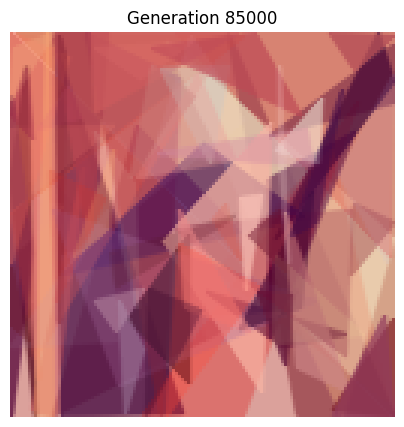

Gen  90000 | tris =  75 | MSE = 357.33


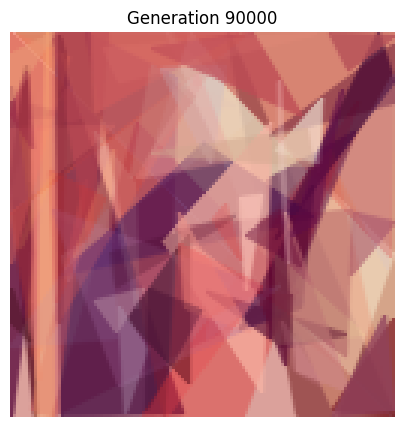

Gen  95000 | tris =  78 | MSE = 348.24


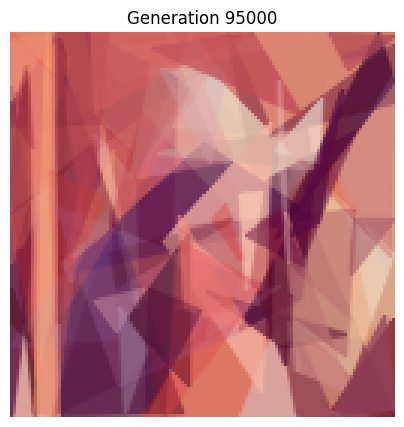

Gen 100000 | tris =  81 | MSE = 333.10


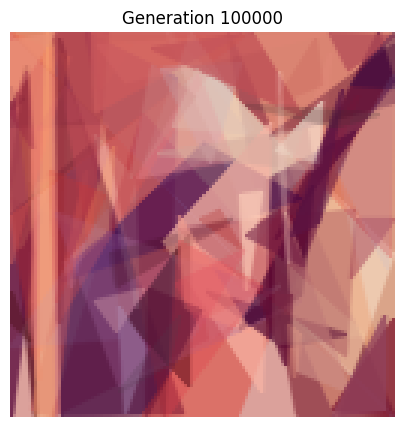

Gen 105000 | tris =  85 | MSE = 319.45


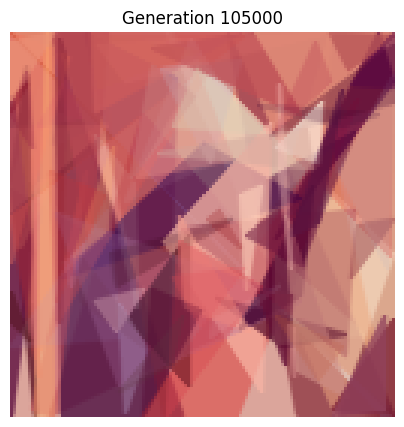

Gen 110000 | tris =  88 | MSE = 304.56


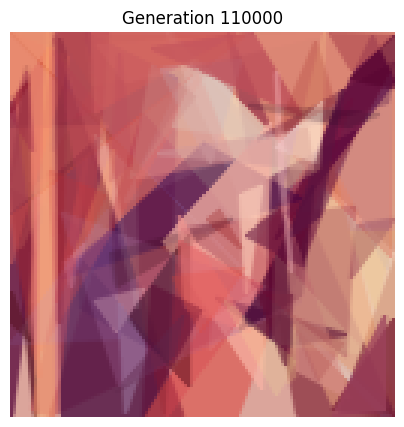

Gen 115000 | tris =  91 | MSE = 294.33


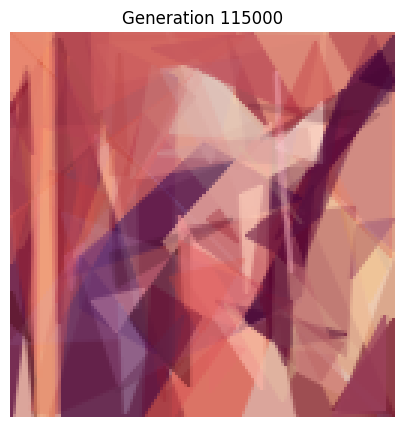

Gen 120000 | tris =  95 | MSE = 283.66


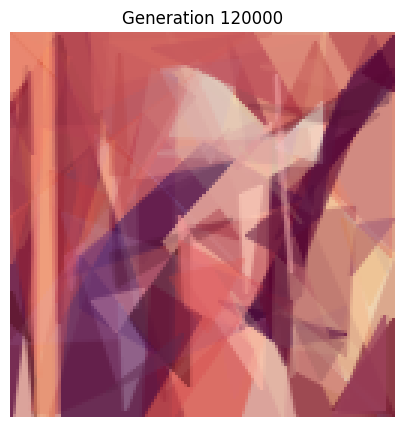

Gen 125000 | tris =  98 | MSE = 272.29


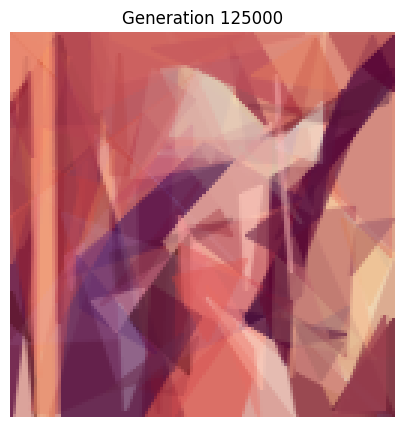

Gen 130000 | tris = 101 | MSE = 263.21


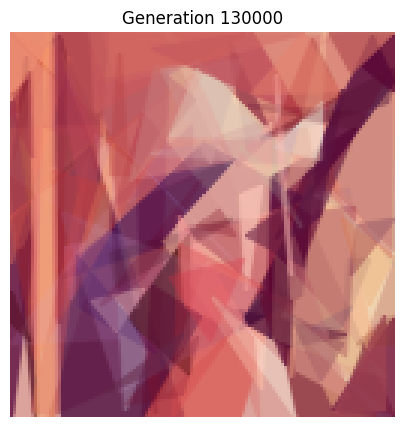

Gen 135000 | tris = 105 | MSE = 256.14


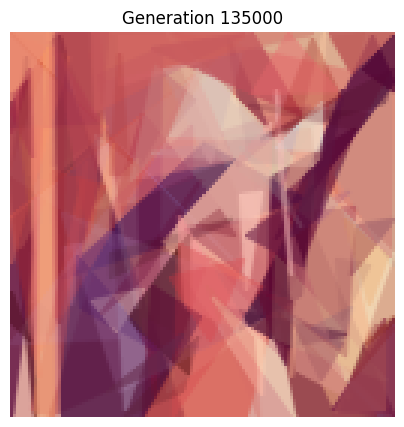

Gen 140000 | tris = 108 | MSE = 247.65


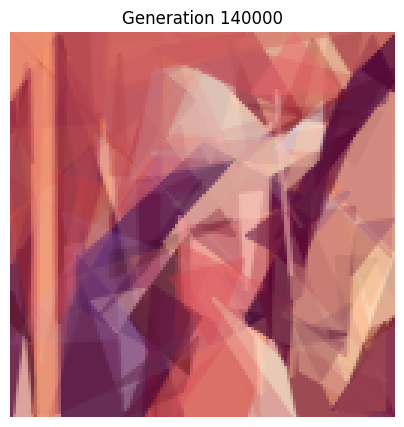

Gen 145000 | tris = 111 | MSE = 241.80


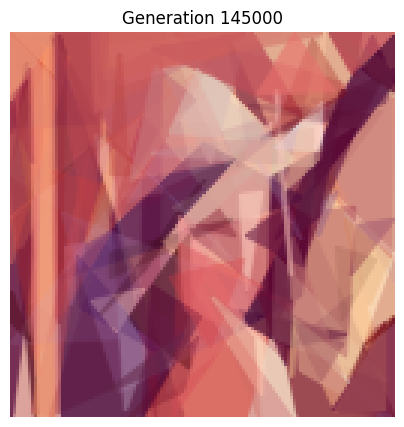

Gen 150000 | tris = 115 | MSE = 235.57


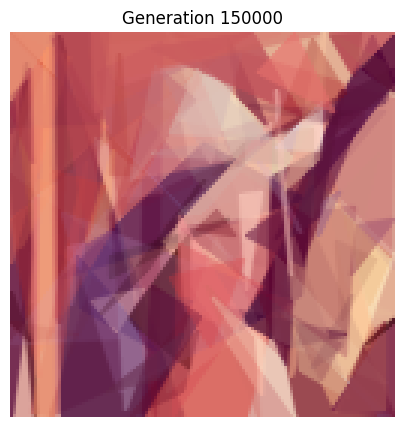

Gen 155000 | tris = 118 | MSE = 229.66


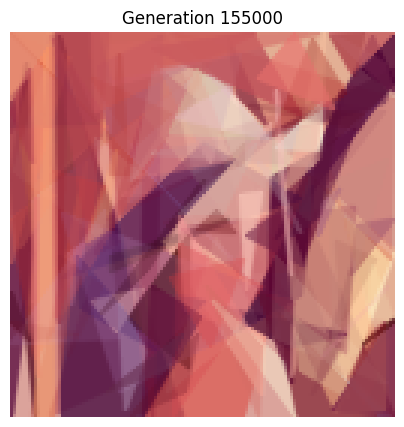

Gen 160000 | tris = 121 | MSE = 223.38


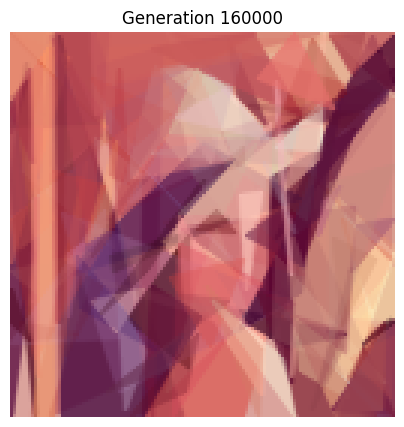

Gen 165000 | tris = 125 | MSE = 218.12


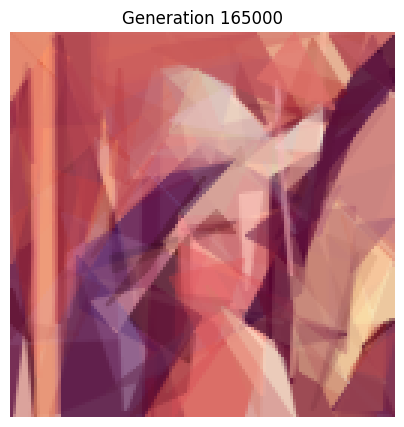

Gen 170000 | tris = 128 | MSE = 214.00


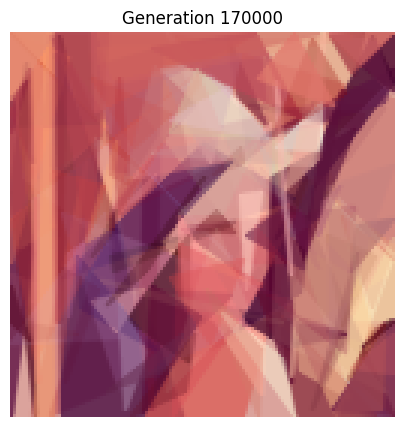

Gen 175000 | tris = 131 | MSE = 209.91


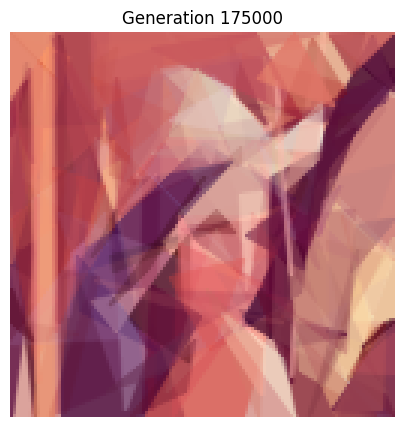

Gen 180000 | tris = 135 | MSE = 206.41


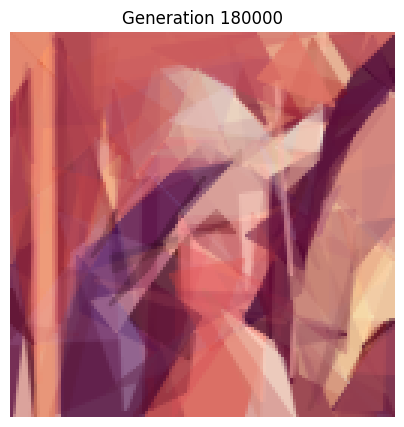

Gen 185000 | tris = 138 | MSE = 202.64


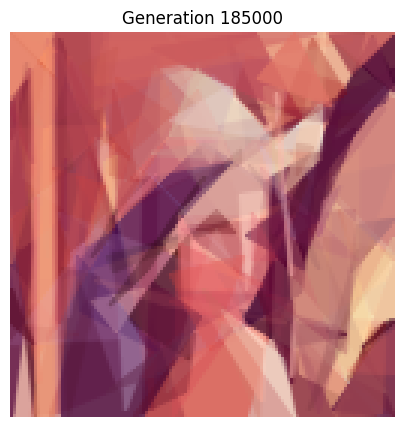

Gen 190000 | tris = 141 | MSE = 199.95


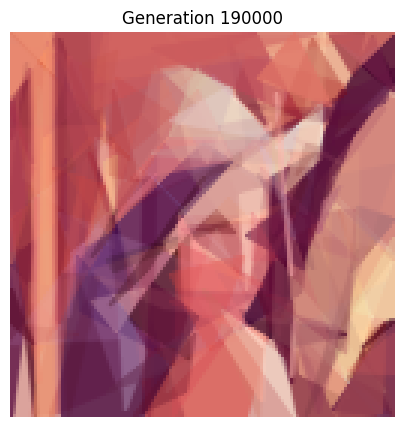

Gen 195000 | tris = 145 | MSE = 197.58


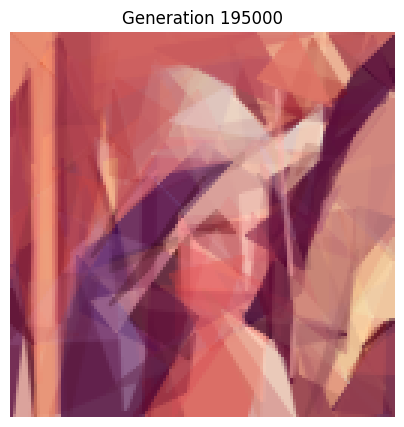

Gen 200000 | tris = 148 | MSE = 195.06


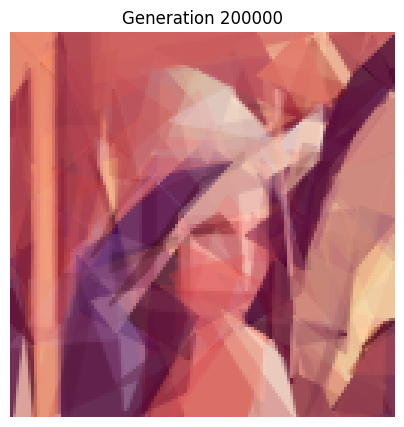

Gen 205000 | tris = 150 | MSE = 192.40


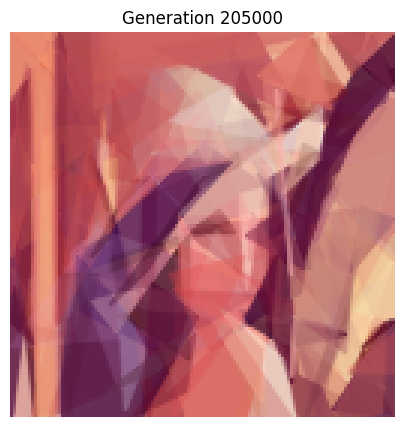

Gen 210000 | tris = 150 | MSE = 190.56


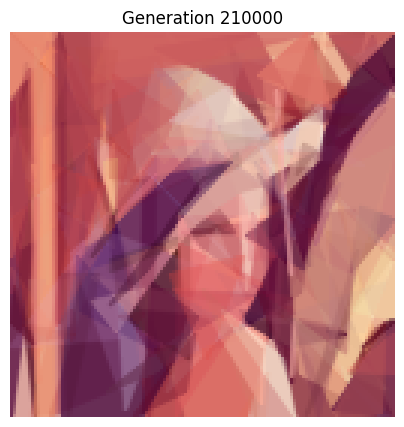

Gen 215000 | tris = 150 | MSE = 188.55


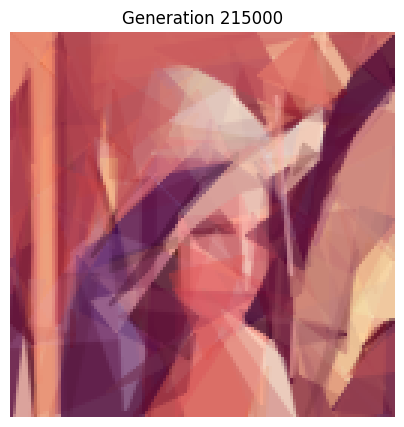

Gen 220000 | tris = 150 | MSE = 187.19


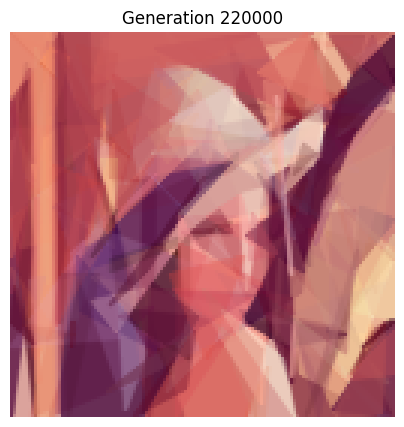

Gen 225000 | tris = 150 | MSE = 185.83


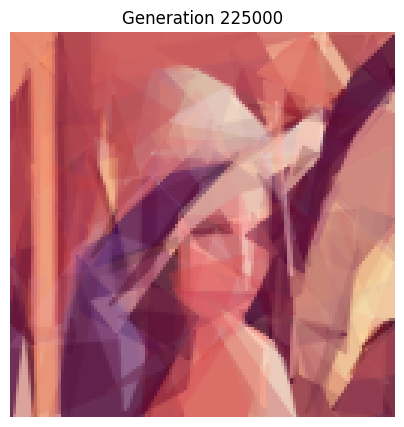

Gen 230000 | tris = 150 | MSE = 184.08


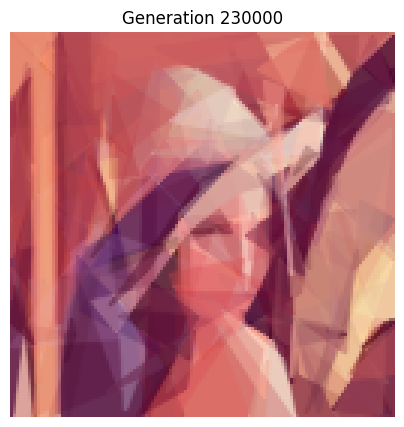

Gen 235000 | tris = 150 | MSE = 182.84


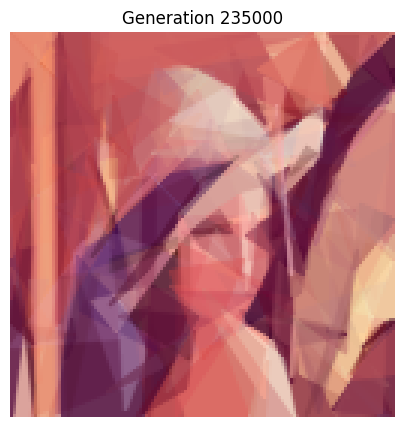

Gen 240000 | tris = 150 | MSE = 181.61


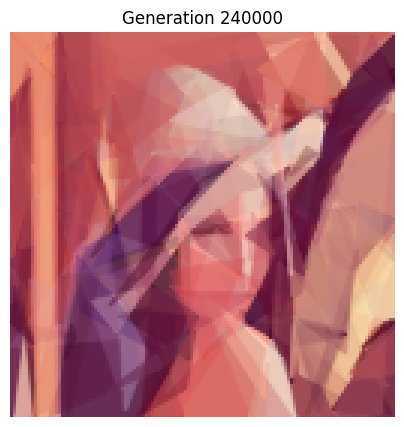

Gen 245000 | tris = 150 | MSE = 180.44


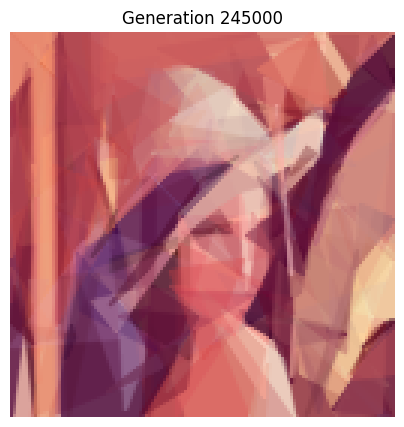

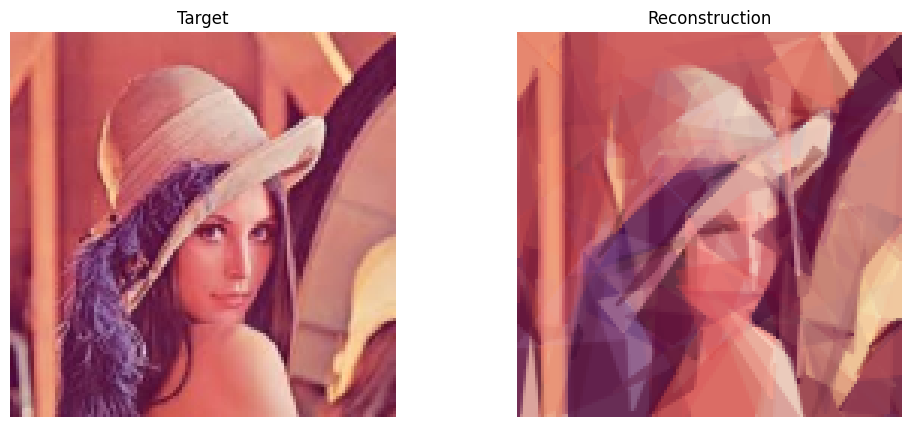

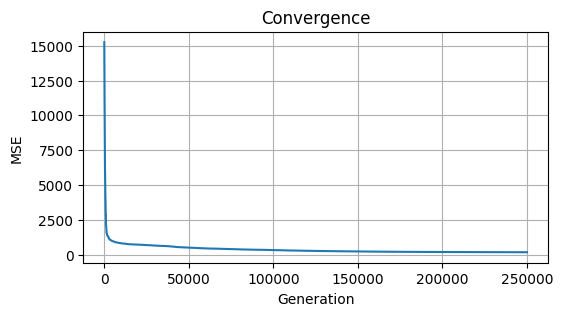

Saved: results/reconstruction.png


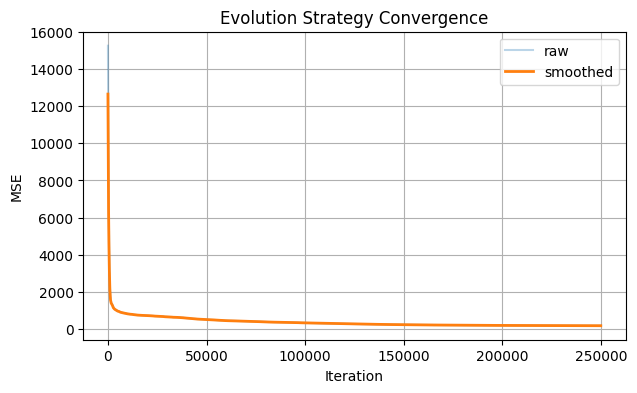


===== FINAL REPORT =====
Final MSE      : 179.47
Triangles      : 150
Image size     : 128x128
Generations    : 250000
SSIM not available (install scikit-image)


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================================
# CONFIG
# ==========================================================

IMAGE = "images/lena.jpg"

SIZE = 128
N_TRIANGLES = 150          # final triangle count
START_TRIANGLES = 15       # progressive growth: start small
GROW_EVERY = 1500          # add 1 triangle every N generations until N_TRIANGLES reached

GENERATIONS = 250000       # (1+1) hill-climbing needs MANY more iterations than 50k
SHOW_EVERY = 5000

# mutation step sizes decay over the run (coarse -> fine search)
VERTEX_SIGMA_START, VERTEX_SIGMA_END = 12, 2
COLOR_SIGMA_START, COLOR_SIGMA_END = 40, 8
ALPHA_SIGMA_START, ALPHA_SIGMA_END = 20, 5

REINIT_PROB = 0.02   # chance to fully randomize a triangle instead of nudging it
                      # (escapes local optima that pure jitter can't)

np.random.seed(42)

# ==========================================================
# LOAD TARGET IMAGE
# ==========================================================

target = cv2.imread(IMAGE)
if target is None:
    raise FileNotFoundError(IMAGE)

target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)
target = cv2.resize(target, (SIZE, SIZE)).astype(np.float32)

# ==========================================================
# CHROMOSOME FORMAT (per triangle): x1 y1 x2 y2 x3 y3 R G B alpha
# ==========================================================

GENES = 10


def random_triangle():
    t = np.empty(GENES, dtype=np.float32)
    t[0:6] = np.random.randint(0, SIZE, 6)
    t[6:9] = np.random.randint(0, 256, 3)
    t[9] = np.random.randint(20, 120)
    return t


def seed_triangle():
    """
    Used when GROWING the population mid-run. Unlike random_triangle(),
    this creates a SMALL, mostly-transparent triangle whose color is
    sampled from the target image at that spot. A newly added triangle
    must not visibly disrupt an already-refined image -- it should blend
    in almost invisibly and get sharpened up by later mutations.
    """
    cx = np.random.randint(0, SIZE)
    cy = np.random.randint(0, SIZE)
    spread = np.random.randint(6, 18)  # small local triangle, not canvas-spanning

    t = np.empty(GENES, dtype=np.float32)
    t[0] = np.clip(cx + np.random.randint(-spread, spread), 0, SIZE - 1)
    t[1] = np.clip(cy + np.random.randint(-spread, spread), 0, SIZE - 1)
    t[2] = np.clip(cx + np.random.randint(-spread, spread), 0, SIZE - 1)
    t[3] = np.clip(cy + np.random.randint(-spread, spread), 0, SIZE - 1)
    t[4] = np.clip(cx + np.random.randint(-spread, spread), 0, SIZE - 1)
    t[5] = np.clip(cy + np.random.randint(-spread, spread), 0, SIZE - 1)

    # sample color from the target at the centroid so it blends in immediately
    t[6:9] = target[cy, cx, :]

    t[9] = np.random.randint(10, 40)  # low alpha -> barely visible at first

    return t


# start with a SMALL population of triangles, grow over time
individual = np.array(
    [random_triangle() for _ in range(START_TRIANGLES)],
    dtype=np.float32
)

overlay = np.empty((SIZE, SIZE, 3), dtype=np.uint8)

print("Initialized:")
print("Target shape :", target.shape)
print("Start tris   :", START_TRIANGLES, "-> growing to", N_TRIANGLES)


# ==========================================================
# RENDER FUNCTION
# ==========================================================

def render(ind):
    canvas = np.full((SIZE, SIZE, 3), 255, dtype=np.uint8)

    for tri in ind:
        overlay[:] = canvas

        pts = np.array([
            [tri[0], tri[1]],
            [tri[2], tri[3]],
            [tri[4], tri[5]]
        ], dtype=np.int32)

        color = (int(tri[6]), int(tri[7]), int(tri[8]))
        alpha = float(tri[9]) / 255.0

        cv2.fillConvexPoly(overlay, pts, color, lineType=cv2.LINE_AA)
        cv2.addWeighted(overlay, alpha, canvas, 1.0 - alpha, 0, dst=canvas)

    return canvas


def fitness(ind):
    img = render(ind)
    diff = img.astype(np.float32) - target
    return np.mean(diff * diff)


# ==========================================================
# INITIAL STATE
# ==========================================================

best = individual.copy()
best_score = fitness(best)
history = []

print("Initial MSE:", best_score)


def lerp(a, b, t):
    return a + (b - a) * t


# ==========================================================
# EVOLUTION LOOP
# ==========================================================

for gen in range(GENERATIONS):

    progress = gen / GENERATIONS  # 0 -> 1, drives mutation-size decay

    # ------------------------------------------------------
    # progressive complexity: add a new triangle periodically
    # ------------------------------------------------------
    if (len(best) < N_TRIANGLES) and (gen % GROW_EVERY == 0) and gen > 0:
        candidate = np.vstack([best, seed_triangle()])
        candidate_score = fitness(candidate)

        # A seed triangle is small + low-alpha + color-matched, so it should
        # barely move the score. Only keep the growth if it doesn't make
        # things meaningfully worse -- never unconditionally accept it.
        if candidate_score <= best_score * 1.01:
            best = candidate
            best_score = candidate_score
        # else: skip growth this round, try again at the next GROW_EVERY tick
        # (len(best) < N_TRIANGLES stays true, so it will retry later)

    child = best.copy()
    n_tris = len(child)

    vertex_sigma = lerp(VERTEX_SIGMA_START, VERTEX_SIGMA_END, progress)
    color_sigma = lerp(COLOR_SIGMA_START, COLOR_SIGMA_END, progress)
    alpha_sigma = lerp(ALPHA_SIGMA_START, ALPHA_SIGMA_END, progress)

    t = np.random.randint(n_tris)

    # ------------------------------------------------------
    # occasionally fully reinitialize a triangle to escape
    # local optima that gradual jitter can't climb out of
    # ------------------------------------------------------
    if np.random.rand() < REINIT_PROB:
        child[t] = random_triangle()
    else:
        n = np.random.randint(1, 4)
        genes = np.random.choice(10, n, replace=False)

        for g in genes:
            if g < 6:
                child[t, g] += np.random.normal(0, vertex_sigma)
            elif g < 9:
                child[t, g] += np.random.normal(0, color_sigma)
            else:
                child[t, g] += np.random.normal(0, alpha_sigma)

    child[:, 0:6] = np.clip(child[:, 0:6], 0, SIZE - 1)
    child[:, 6:9] = np.clip(child[:, 6:9], 0, 255)
    child[:, 9] = np.clip(child[:, 9], 5, 200)

    score = fitness(child)

    if score < best_score:
        best = child
        best_score = score

    history.append(best_score)

    if gen % SHOW_EVERY == 0:
        print(f"Gen {gen:6d} | tris = {len(best):3d} | MSE = {best_score:.2f}")

        plt.figure(figsize=(5, 5))
        plt.imshow(render(best))
        plt.axis("off")
        plt.title(f"Generation {gen}")
        plt.show()


# ==========================================================
# FINAL OUTPUT
# ==========================================================

final_img = render(best)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(target.astype(np.uint8))
plt.title("Target")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(final_img)
plt.title("Reconstruction")
plt.axis("off")
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(history)
plt.title("Convergence")
plt.xlabel("Generation")
plt.ylabel("MSE")
plt.grid()
plt.show()

os.makedirs("results", exist_ok=True)
cv2.imwrite("results/reconstruction.png", cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR))
print("Saved: results/reconstruction.png")

history_np = np.array(history)
window = 200
if len(history_np) > window:
    smooth = np.convolve(history_np, np.ones(window) / window, mode='valid')
else:
    smooth = history_np

plt.figure(figsize=(7, 4))
plt.plot(history_np, alpha=0.3, label="raw")
plt.plot(smooth, linewidth=2, label="smoothed")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Evolution Strategy Convergence")
plt.legend()
plt.grid()
plt.show()

print("\n===== FINAL REPORT =====")
print(f"Final MSE      : {best_score:.2f}")
print(f"Triangles      : {len(best)}")
print(f"Image size     : {SIZE}x{SIZE}")
print(f"Generations    : {GENERATIONS}")
print("========================")

try:
    from skimage.metrics import structural_similarity as ssim
    score = ssim(target, final_img, channel_axis=2)
    print(f"SSIM Score     : {score:.4f}")
except Exception:
    print("SSIM not available (install scikit-image)")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
grid_size = 100
num_generations = 100
population_size = 20
mutation_rate = 0.01

# Initialize population
def initialize_population(size, grid_size):
    return [np.random.randint(2, size=(grid_size, grid_size)) for _ in range(size)]

# Fitness function
def fitness(individual):
    return np.sum(individual)

# Selection
def select(population, fitnesses):
    idx = np.random.choice(len(population), size=len(population), p=fitnesses/np.sum(fitnesses))
    return [population[i] for i in idx]

# Crossover
def crossover(parent1, parent2):
    crossover_point = np.random.randint(0, parent1.size)
    child = np.copy(parent1)
    child.flat[crossover_point:] = parent2.flat[crossover_point:]
    return child

# Mutation
def mutate(individual, rate):
    mutation_mask = np.random.rand(*individual.shape) < rate
    individual[mutation_mask] = 1 - individual[mutation_mask]
    return individual

# Cellular automata rules
def apply_rules(grid):
    new_grid = np.copy(grid)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            total = np.sum(grid[max(0, i-1):min(grid.shape[0], i+2), max(0, j-1):min(grid.shape[1], j+2)]) - grid[i, j]
            if grid[i, j] == 1 and (total < 2 or total > 3):
                new_grid[i, j] = 0
            elif grid[i, j] == 0 and total == 3:
                new_grid[i, j] = 1
    return new_grid

# Main GA loop
population = initialize_population(population_size, grid_size)
for generation in range(num_generations):
    fitnesses = np.array([fitness(ind) for ind in population])
    population = select(population, fitnesses)
    next_population = []
    for i in range(0, population_size, 2):
        parent1, parent2 = population[i], population[i+1]
        child1, child2 = crossover(parent1, parent2), crossover(parent2, parent1)
        next_population.extend([mutate(child1, mutation_rate), mutate(child2, mutation_rate)])
    population = next_population
    if generation % 10 == 0:
        best_individual = population[np.argmax(fitnesses)]
        plt.imshow(best_individual, cmap='binary')
        plt.title(f'Generation {generation}')
        plt.show()

# Display final result
best_individual = population[np.argmax(fitnesses)]
plt.imshow(best_individual, cmap='binary')
plt.title('Final Result')
plt.show()

### **Image Denoising with Genetic Algorithm**

Gen   0 | Fitness(energy) -0.03309 | True PSNR vs clean 27.56 dB | PSNR vs noisy 22.41 dB
Gen   1 | Fitness(energy) -0.03273 | True PSNR vs clean 27.57 dB | PSNR vs noisy 22.32 dB
Gen   2 | Fitness(energy) -0.03246 | True PSNR vs clean 27.59 dB | PSNR vs noisy 22.26 dB
Gen   3 | Fitness(energy) -0.03214 | True PSNR vs clean 27.60 dB | PSNR vs noisy 22.18 dB
Gen   4 | Fitness(energy) -0.03183 | True PSNR vs clean 27.62 dB | PSNR vs noisy 22.10 dB
Gen   5 | Fitness(energy) -0.03150 | True PSNR vs clean 27.63 dB | PSNR vs noisy 22.03 dB
Gen   6 | Fitness(energy) -0.03131 | True PSNR vs clean 27.64 dB | PSNR vs noisy 21.98 dB
Gen   7 | Fitness(energy) -0.03098 | True PSNR vs clean 27.65 dB | PSNR vs noisy 21.90 dB
Gen   8 | Fitness(energy) -0.03074 | True PSNR vs clean 27.66 dB | PSNR vs noisy 21.84 dB
Gen   9 | Fitness(energy) -0.03045 | True PSNR vs clean 27.67 dB | PSNR vs noisy 21.78 dB
Gen  10 | Fitness(energy) -0.03022 | True PSNR vs clean 27.68 dB | PSNR vs noisy 21.72 dB
Gen  11 | 

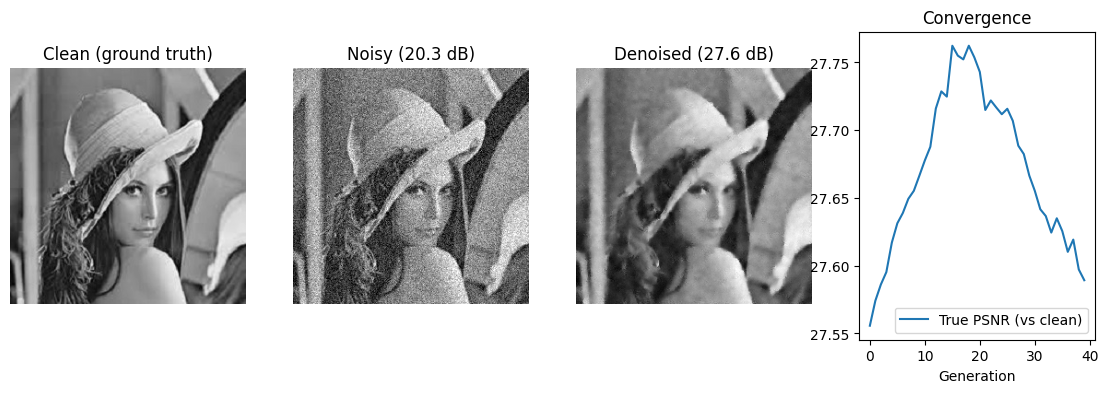

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from skimage.metrics import structural_similarity as ssim

# =========================================================
# LOAD IMAGE
# =========================================================
img = cv2.imread("images/lena.jpg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found")

img = img.astype(np.float32)

# Add synthetic noise
np.random.seed(0)
noisy_image = img + np.random.normal(0, 25, img.shape)
noisy_image = np.clip(noisy_image, 0, 255)

H, W = img.shape

# =========================================================
# PATCH SETTINGS
# =========================================================
PATCH_SIZE = 8
N_PATCHES = 50
POP_SIZE = 20
GENERATIONS = 40
MUTATION_RATE = 0.2
TOURNAMENT_K = 3

# LAMBDA_TV controls the fidelity-vs-smoothness tradeoff.
# Too low -> noise survives. Too high -> over-smoothed / blurry, loses detail.
# Tune this per noise level; 0.3-0.6 is a reasonable starting range for sigma=25.
LAMBDA_TV = 0.4

# =========================================================
# METRICS
# =========================================================
def psnr(a, b):
    mse = np.mean((a - b) ** 2)
    if mse == 0:
        return 100
    return 20 * np.log10(255.0 / np.sqrt(mse))

def tv(image):
    return np.mean(np.abs(np.diff(image, axis=0))) + np.mean(np.abs(np.diff(image, axis=1)))

# =========================================================
# FITNESS -- BLIND VARIATIONAL DENOISING ENERGY
# =========================================================
# CRITICAL FIX: this must NEVER reference the clean ground-truth `img`.
# Real denoising has no access to the clean image at inference time --
# a fitness that compares against `img` would trivially "solve" the
# problem by copying it, which isn't a real algorithm.
#
# Also critical: the OLD fitness rewarded similarity to the NOISY image,
# which directly rewards keeping noise. This is a proper ROF/TV-style
# energy instead: minimize (data fidelity to noisy) + lambda * (smoothness).
# Maximizing fitness = minimizing that energy.
def fitness(ind):
    ind = np.clip(ind, 0, 255).astype(np.float32)
    data_term = np.mean((ind - noisy_image) ** 2) / (255.0 ** 2)
    tv_term = tv(ind) / 255.0
    energy = data_term + LAMBDA_TV * tv_term
    return -energy

# =========================================================
# TRUE EVALUATION (ground truth -- for REPORTING ONLY, never for fitness)
# =========================================================
def true_psnr(ind):
    return psnr(img, ind)

def true_ssim(ind):
    return ssim(img, np.clip(ind, 0, 255).astype(np.float32), data_range=255.0)

# =========================================================
# INITIAL POPULATION
# =========================================================
# FIX: the old version ADDED extra noise on top of noisy_image, so the GA
# had to spend most of its budget just recovering back to the starting
# point. Instead, seed with a real classical denoiser (bilateral filter)
# at varying strengths -- this gives the GA a real head start, and the
# varying strengths give the population diversity to explore from.
def init_population():
    pop = []
    for i in range(POP_SIZE):
        d = np.random.uniform(0, 1)  # varying denoise strength per individual
        sigma_color = 10 + 40 * d
        sigma_space = 3 + 12 * d
        base = cv2.bilateralFilter(
            noisy_image.astype(np.float32), d=9,
            sigmaColor=sigma_color, sigmaSpace=sigma_space
        )
        pop.append(np.clip(base, 0, 255))
    return pop

# =========================================================
# PATCH MUTATION (LOCAL REFINEMENT)
# =========================================================
# FIX: old version only touched 5 random patches per call -- for a large
# image that's a tiny fraction of total patches, so most of the image
# never got refined across 40 generations. Sweep far more patches per
# mutation call so the whole image gets meaningfully touched.
N_MUTATION_PATCHES = 200  # was 5 -- raise/lower based on runtime budget

def mutate(ind):
    ind = ind.copy()
    for _ in range(N_MUTATION_PATCHES):
        if np.random.rand() < MUTATION_RATE:
            x = np.random.randint(0, H - PATCH_SIZE)
            y = np.random.randint(0, W - PATCH_SIZE)
            patch = ind[x:x+PATCH_SIZE, y:y+PATCH_SIZE]
            noise = np.random.normal(0, 6, patch.shape)      # smaller exploration noise
            smooth = cv2.GaussianBlur(patch, (3, 3), 0)
            patch = patch + 0.3 * noise + 0.7 * (smooth - patch)  # bias toward smoothing
            ind[x:x+PATCH_SIZE, y:y+PATCH_SIZE] = patch
    return np.clip(ind, 0, 255)

# =========================================================
# CROSSOVER (PATCH SWAP)
# =========================================================
def crossover(a, b):
    child = a.copy()
    for _ in range(5):
        x = np.random.randint(0, H - PATCH_SIZE)
        y = np.random.randint(0, W - PATCH_SIZE)
        if np.random.rand() < 0.5:
            child[x:x+PATCH_SIZE, y:y+PATCH_SIZE] = b[x:x+PATCH_SIZE, y:y+PATCH_SIZE]
    return child

# =========================================================
# SELECTION -- FIX: was uniform random, ignored fitness entirely
# =========================================================
def tournament_select(pop, scores):
    idx = np.random.choice(len(pop), TOURNAMENT_K, replace=False)
    best_idx = idx[np.argmax(scores[idx])]
    return pop[best_idx]

# =========================================================
# INIT
# =========================================================
population = init_population()

history_fitness = []
history_true_psnr = []   # what actually matters -- vs clean image

# =========================================================
# EVOLUTION LOOP
# =========================================================
for gen in range(GENERATIONS):

    scores = np.array([fitness(ind) for ind in population])
    idx = np.argmax(scores)
    best_ind = population[idx]

    history_fitness.append(scores[idx])
    history_true_psnr.append(true_psnr(best_ind))

    print(f"Gen {gen:3d} | Fitness(energy) {scores[idx]:.5f} | "
          f"True PSNR vs clean {history_true_psnr[-1]:.2f} dB | "
          f"PSNR vs noisy {psnr(noisy_image, best_ind):.2f} dB")

    elite = population[idx].copy()
    new_pop = [elite]

    while len(new_pop) < POP_SIZE:
        p1 = tournament_select(population, scores)
        p2 = tournament_select(population, scores)
        child = crossover(p1, p2)
        child = mutate(child)
        new_pop.append(child)

    population = new_pop

# =========================================================
# FINAL OUTPUT
# =========================================================
final_scores = [fitness(p) for p in population]
final_img = population[np.argmax(final_scores)]

print("\n===== FINAL REPORT =====")
print(f"Noisy input PSNR vs clean : {psnr(img, noisy_image):.2f} dB  (baseline, no denoising)")
print(f"GA result PSNR vs clean   : {true_psnr(final_img):.2f} dB")
print(f"GA result SSIM vs clean   : {true_ssim(final_img):.4f}")
print("========================")

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title(f"Clean (ground truth)")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title(f"Noisy ({psnr(img, noisy_image):.1f} dB)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(final_img, cmap='gray')
plt.title(f"Denoised ({true_psnr(final_img):.1f} dB)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.plot(history_true_psnr, label="True PSNR (vs clean)")
plt.legend()
plt.title("Convergence")
plt.xlabel("Generation")
plt.show()

### Image Contrast Enhancement with Genetic Algorithms

In [ ]:
import cv2
import numpy as np
from skimage.metrics import entropy

# Parameters
population_size = 20
num_generations = 50
mutation_rate = 0.1
image_path = 'path_to_image.jpg'

# Load image
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Initialize population
def initialize_population(size):
    return np.random.uniform(0.1, 2.0, size)

# Fitness function
def fitness(individual, image):
    enhanced_image = cv2.equalizeHist((image * individual).astype(np.uint8))
    return entropy(enhanced_image)

# Selection
def select(population, fitnesses):
    idx = np.random.choice(len(population), size=len(population), p=fitnesses/np.sum(fitnesses))
    return population[idx]

# Crossover
def crossover(parent1, parent2):
    return (parent1 + parent2) / 2

# Mutation
def mutate(individual, rate):
    if np.random.rand() < rate:
        individual += np.random.uniform(-0.1, 0.1)
    return individual

# Main GA loop
population = initialize_population(population_size)
for generation in range(num_generations):
    fitnesses = np.array([fitness(ind, image) for ind in population])
    population = select(population, fitnesses)
    next_population = []
    for i in range(0, population_size, 2):
        parent1, parent2 = population[i], population[i+1]
        child1, child2 = crossover(parent1, parent2), crossover(parent2, parent1)
        next_population.extend([mutate(child1, mutation_rate), mutate(child2, mutation_rate)])
    population = next_population
    if generation % 10 == 0:
        best_individual = population[np.argmax(fitnesses)]
        enhanced_image = cv2.equalizeHist((image * best_individual).astype(np.uint8))
        cv2.imshow(f'Generation {generation}', enhanced_image)
        cv2.waitKey(1)

# Display final result
best_individual = population[np.argmax(fitnesses)]
enhanced_image = cv2.equalizeHist((image * best_individual).astype(np.uint8))
cv2.imshow('Final Result', enhanced_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
import cv2
import numpy as np
from skimage.metrics import entropy

# Parameters
population_size = 20
num_generations = 50
mutation_rate = 0.1
image_path = 'path_to_image.jpg'

# Load image
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Initialize population
def initialize_population(size, shape):
    return [cv2.normalize(image + np.random.normal(0, 25, shape), None, 0, 255, cv2.NORM_MINMAX) for _ in range(size)]

# Fitness function
def fitness(individual, image):
    return entropy(individual)

# Selection
def select(population, fitnesses):
    idx = np.random.choice(len(population), size=len(population), p=fitnesses/np.sum(fitnesses))
    return [population[i] for i in idx]

# Crossover
def crossover(parent1, parent2):
    crossover_point = np.random.randint(0, parent1.size)
    child = np.copy(parent1)
    child.flat[crossover_point:] = parent2.flat[crossover_point:]
    return child

# Mutation
def mutate(individual, rate):
    mutation_mask = np.random.rand(*individual.shape) < rate
    individual[mutation_mask] += np.random.normal(0, 25, np.sum(mutation_mask))
    return cv2.normalize(individual, None, 0, 255, cv2.NORM_MINMAX)

# Main GA loop
population = initialize_population(population_size, image.shape)
for generation in range(num_generations):
    fitnesses = np.array([fitness(ind, image) for ind in population])
    population = select(population, fitnesses)
    next_population = []
    for i in range(0, population_size, 2):
        parent1, parent2 = population[i], population[i+1]
        child1, child2 = crossover(parent1, parent2), crossover(parent2, parent1)
        next_population.extend([mutate(child1, mutation_rate), mutate(child2, mutation_rate)])
    population = next_population
    if generation % 10 == 0:
        best_individual = population[np.argmax(fitnesses)]
        cv2.imshow(f'Generation {generation}', best_individual)
        cv2.waitKey(1)

# Display final result
best_individual = population[np.argmax(fitnesses)]
cv2.imshow('Final Result', best_individual)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Image Segmentation with Genetic Algorithms

In [ ]:
import cv2
import numpy as np
from skimage.metrics import adapted_rand_error

# Parameters
population_size = 20
num_generations = 50
mutation_rate = 0.1
image_path = 'path_to_image.jpg'

# Load image
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Initialize population
def initialize_population(size):
    return np.random.randint(0, 256, size)

# Fitness function
def fitness(individual, image):
    _, segmented_image = cv2.threshold(image, individual, 255, cv2.THRESH_BINARY)
    return -adapted_rand_error(image, segmented_image)[0]

# Selection
def select(population, fitnesses):
    idx = np.random.choice(len(population), size=len(population), p=fitnesses/np.sum(fitnesses))
    return population[idx]

# Crossover
def crossover(parent1, parent2):
    return (parent1 + parent2) // 2

# Mutation
def mutate(individual, rate):
    if np.random.rand() < rate:
        individual += np.random.randint(-10, 10)
    return np.clip(individual, 0, 255)

# Main GA loop
population = initialize_population(population_size)
for generation in range(num_generations):
    fitnesses = np.array([fitness(ind, image) for ind in population])
    population = select(population, fitnesses)
    next_population = []
    for i in range(0, population_size, 2):
        parent1, parent2 = population[i], population[i+1]
        child1, child2 = crossover(parent1, parent2), crossover(parent2, parent1)
        next_population.extend([mutate(child1, mutation_rate), mutate(child2, mutation_rate)])
    population = next_population
    if generation % 10 == 0:
        best_individual = population[np.argmax(fitnesses)]
        _, segmented_image = cv2.threshold(image, best_individual, 255, cv2.THRESH_BINARY)
        cv2.imshow(f'Generation {generation}', segmented_image)
        cv2.waitKey(1)

# Display final result
best_individual = population[np.argmax(fitnesses)]
_, segmented_image = cv2.threshold(image, best_individual, 255, cv2.THRESH_BINARY)
cv2.imshow('Final Result', segmented_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
import cv2
import numpy as np
from skimage.metrics import adapted_rand_error

# Parameters
population_size = 20
num_generations = 50
mutation_rate = 0.1
image_path = 'path_to_image.jpg'

# Load image
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Initialize population
def initialize_population(size, shape):
    return [np.random.randint(0, 2, shape, dtype=np.uint8) * 255 for _ in range(size)]

# Fitness function
def fitness(individual, image):
    return -adapted_rand_error(image, individual)[0]

# Selection
def select(population, fitnesses):
    idx = np.random.choice(len(population), size=len(population), p=fitnesses/np.sum(fitnesses))
    return [population[i] for i in idx]

# Crossover
def crossover(parent1, parent2):
    crossover_point = np.random.randint(0, parent1.size)
    child = np.copy(parent1)
    child.flat[crossover_point:] = parent2.flat[crossover_point:]
    return child

# Mutation
def mutate(individual, rate):
    mutation_mask = np.random.rand(*individual.shape) < rate
    individual[mutation_mask] = 255 - individual[mutation_mask]
    return individual

# Main GA loop
population = initialize_population(population_size, image.shape)
for generation in range(num_generations):
    fitnesses = np.array([fitness(ind, image) for ind in population])
    population = select(population, fitnesses)
    next_population = []
    for i in range(0, population_size, 2):
        parent1, parent2 = population[i], population[i+1]
        child1, child2 = crossover(parent1, parent2), crossover(parent2, parent1)
        next_population.extend([mutate(child1, mutation_rate), mutate(child2, mutation_rate)])
    population = next_population
    if generation % 10 == 0:
        best_individual = population[np.argmax(fitnesses)]
        cv2.imshow(f'Generation {generation}', best_individual)
        cv2.waitKey(1)

# Display final result
best_individual = population[np.argmax(fitnesses)]
cv2.imshow('Final Result', best_individual)
cv2.waitKey(0)
cv2.destroyAllWindows()

### **Edge Detection with Ant Colony Optimization**

Iteration 01/40 | Mean=0.856 | Max=1.600
Iteration 02/40 | Mean=0.732 | Max=1.647
Iteration 03/40 | Mean=0.627 | Max=1.822
Iteration 04/40 | Mean=0.537 | Max=1.686
Iteration 05/40 | Mean=0.461 | Max=1.783
Iteration 06/40 | Mean=0.397 | Max=1.515
Iteration 07/40 | Mean=0.344 | Max=1.751
Iteration 08/40 | Mean=0.297 | Max=1.957
Iteration 09/40 | Mean=0.257 | Max=1.827
Iteration 10/40 | Mean=0.222 | Max=1.770
Iteration 11/40 | Mean=0.193 | Max=2.112
Iteration 12/40 | Mean=0.171 | Max=2.083
Iteration 13/40 | Mean=0.150 | Max=2.130
Iteration 14/40 | Mean=0.134 | Max=2.328
Iteration 15/40 | Mean=0.119 | Max=2.212
Iteration 16/40 | Mean=0.106 | Max=2.057
Iteration 17/40 | Mean=0.095 | Max=1.876
Iteration 18/40 | Mean=0.085 | Max=2.009
Iteration 19/40 | Mean=0.077 | Max=1.840
Iteration 20/40 | Mean=0.070 | Max=2.214
Iteration 21/40 | Mean=0.063 | Max=2.270
Iteration 22/40 | Mean=0.059 | Max=1.930
Iteration 23/40 | Mean=0.052 | Max=2.277
Iteration 24/40 | Mean=0.049 | Max=1.935
Iteration 25/40 

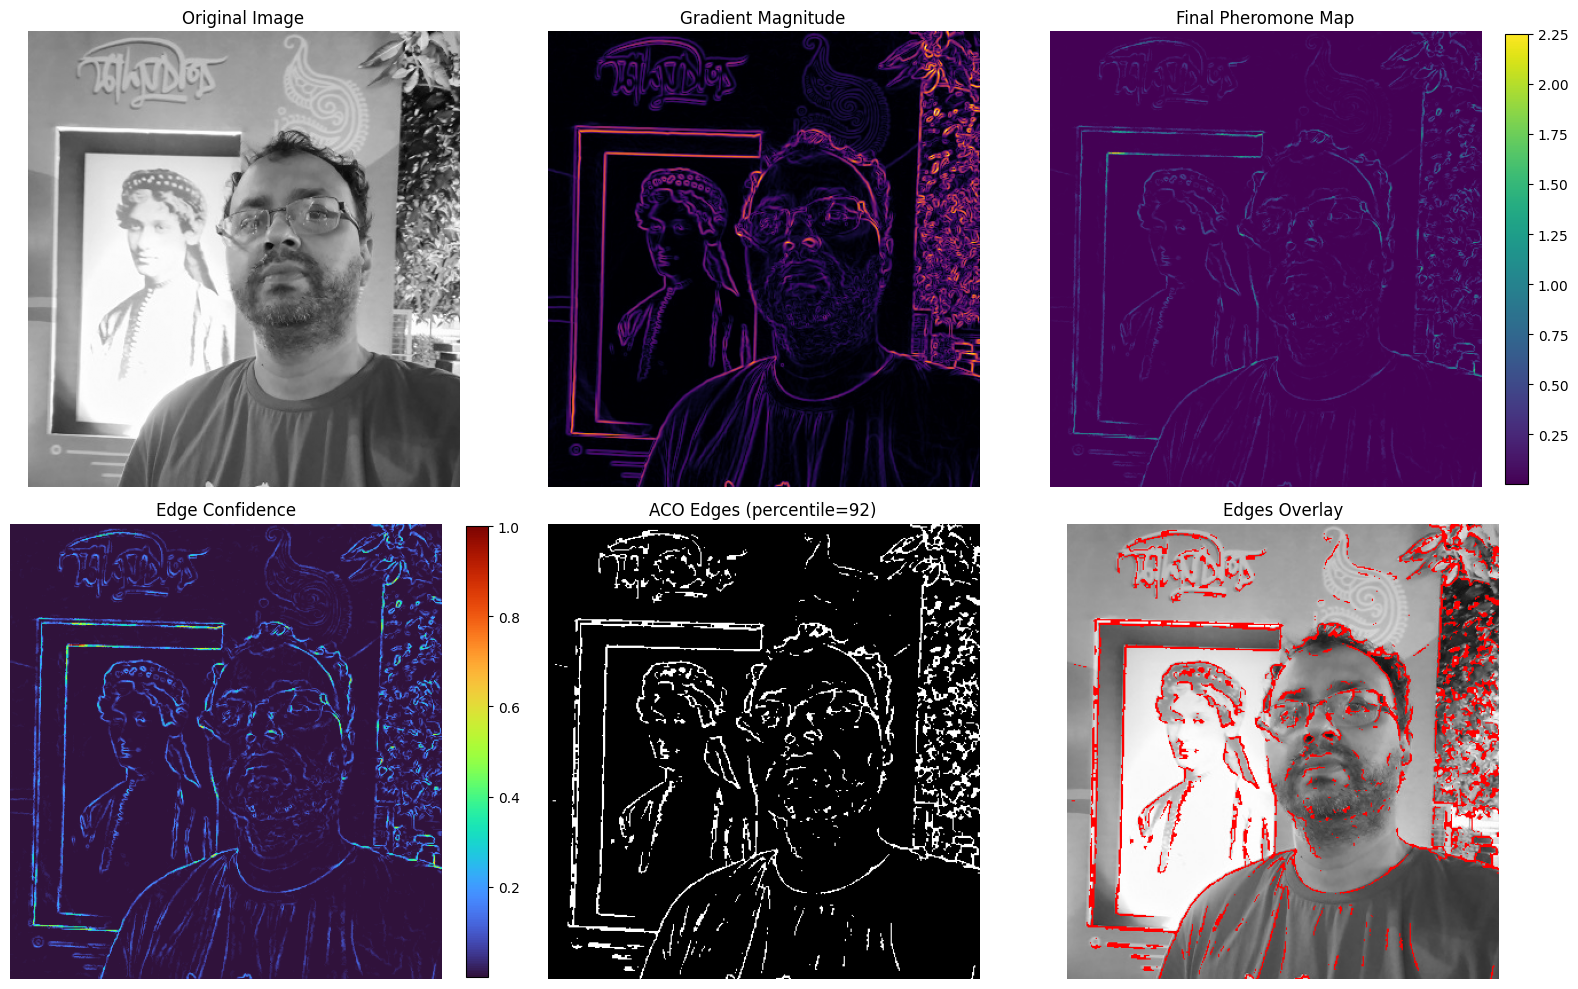

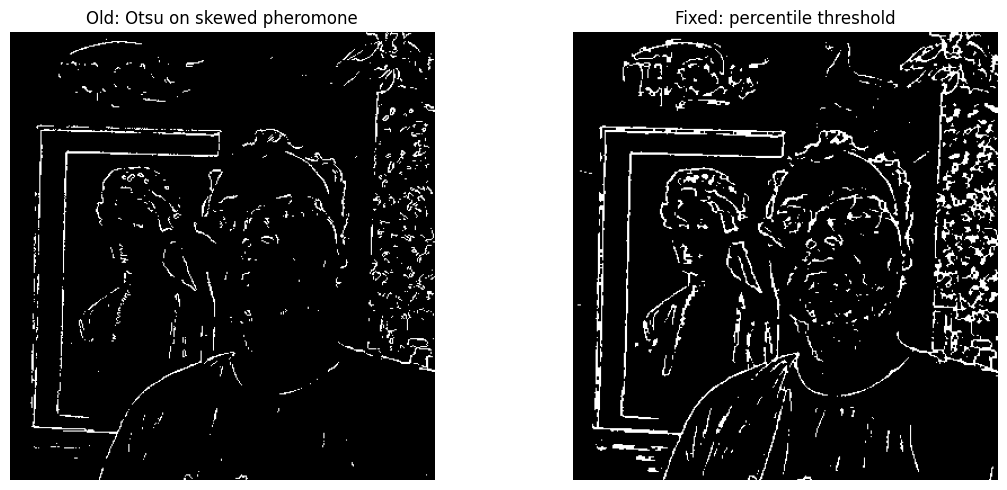

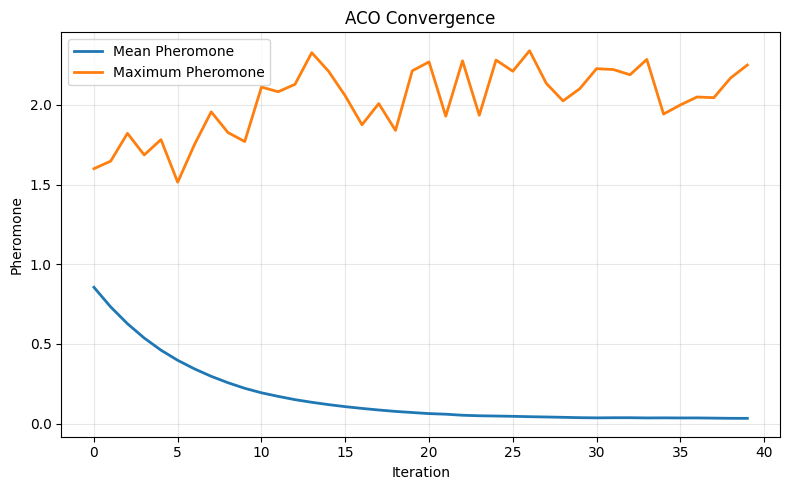

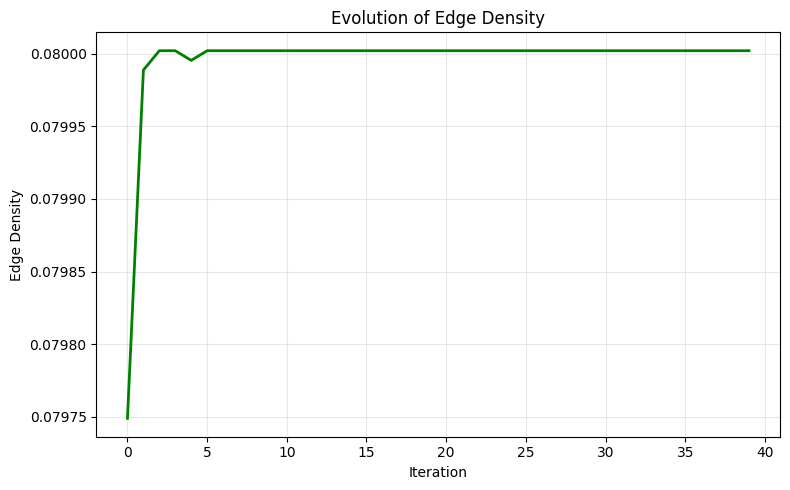

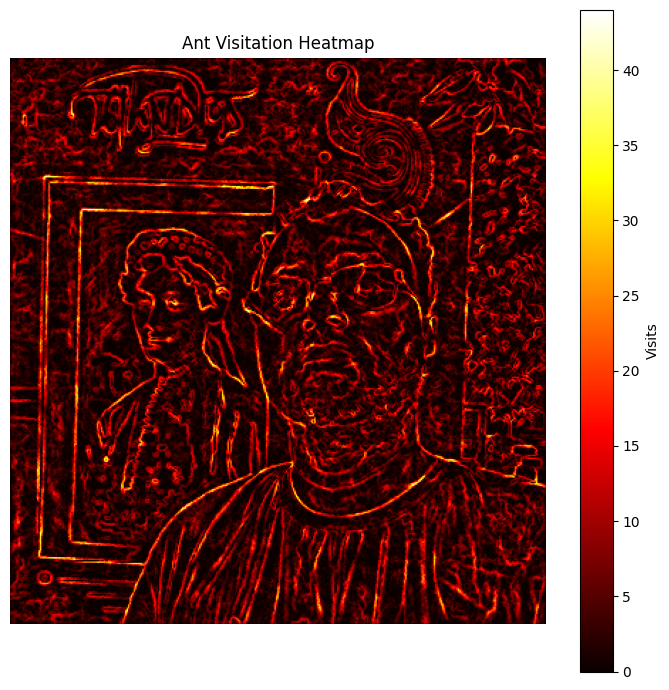

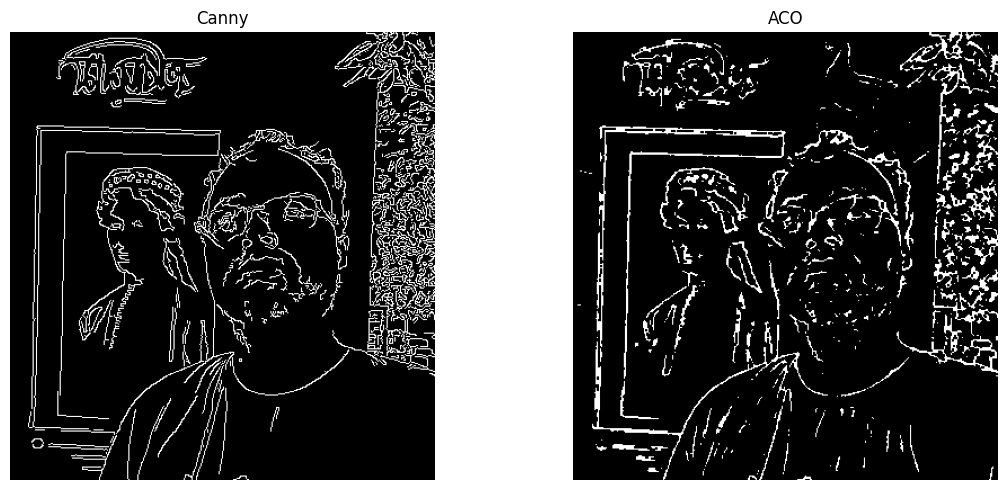


Finished.


In [15]:
# ==========================================================
# Ant Colony Optimization (ACO) for Edge Detection -- FIXED
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PARAMETERS
# ==========================================================
IMAGE_PATH = "images/me.jpg"

NUM_ANTS = 500
NUM_ITER = 40
STEPS = 30

ALPHA = 1.0          # pheromone importance
BETA = 2.0           # heuristic importance
RHO = 0.15           # evaporation -- raised from 0.08, helps counter runaway growth
Q = 5.0              # pheromone deposit

EDGE_PERCENTILE = 92  # final edge threshold: top (100-EDGE_PERCENTILE)% of pheromone

np.random.seed(0)

# ==========================================================
# LOAD IMAGE
# ==========================================================
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Cannot load image.")

img = img.astype(np.float32)
H, W = img.shape

# ==========================================================
# COMPUTE HEURISTIC (Gradient Magnitude)
# ==========================================================
gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
grad = np.sqrt(gx**2 + gy**2)
grad /= grad.max() + 1e-8
heuristic = grad + 1e-6

# ==========================================================
# INITIAL PHEROMONE
# ==========================================================
pheromone = np.ones((H, W), dtype=np.float32)
visit_map = np.zeros((H, W), dtype=np.float32)

history_mean = []
history_max = []
edge_density = []

# 8-neighbour connectivity
moves = [
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1),           (0, 1),
    (1, -1),  (1, 0),  (1, 1)
]

# ==========================================================
# MAIN ACO LOOP
# ==========================================================
for iteration in range(NUM_ITER):

    delta = np.zeros_like(pheromone)

    for ant in range(NUM_ANTS):

        x = np.random.randint(1, H - 1)
        y = np.random.randint(1, W - 1)

        # FIX: tabu set -- prevents an ant from oscillating back and forth
        # between the same couple of high-gradient neighbors, which is what
        # was causing pheromone to pile up on a tiny handful of pixels
        # instead of spreading along the actual edge contour.
        visited = {(x, y)}

        for step in range(STEPS):

            candidates = []
            weights = []

            for dx, dy in moves:
                nx, ny = x + dx, y + dy

                if 0 <= nx < H and 0 <= ny < W and (nx, ny) not in visited:
                    tau = pheromone[nx, ny] ** ALPHA
                    eta = heuristic[nx, ny] ** BETA
                    candidates.append((nx, ny))
                    weights.append(tau * eta)

            if not candidates:
                # ant is boxed in by its own tabu history -- release the
                # oldest constraint by allowing revisits, rather than
                # silently dying (which biases coverage toward whichever
                # spots ants got trapped near first)
                visited.clear()
                visited.add((x, y))
                continue

            weights = np.asarray(weights, dtype=np.float64)
            if weights.sum() == 0:
                break
            weights /= weights.sum()

            idx = np.random.choice(len(candidates), p=weights)
            x, y = candidates[idx]
            visited.add((x, y))

            visit_map[x, y] += 1
            delta[x, y] += Q * heuristic[x, y]

    # FIX: normalize the deposit before merging it in. Without this, a few
    # heavily-visited pixels accumulate pheromone that's orders of
    # magnitude larger than everywhere else, which later wrecks min-max
    # normalization and Otsu thresholding (crushes real edges to near-zero
    # contrast, leaves only extreme outliers above threshold).
    if delta.max() > 0:
        delta = delta / delta.max()

    pheromone = (1 - RHO) * pheromone + RHO * delta * (Q)

    history_mean.append(pheromone.mean())
    history_max.append(pheromone.max())

    threshold = np.percentile(pheromone, EDGE_PERCENTILE)
    edge_density.append(np.mean(pheromone > threshold))

    print(
        f"Iteration {iteration+1:02d}/{NUM_ITER} | "
        f"Mean={history_mean[-1]:.3f} | "
        f"Max={history_max[-1]:.3f}"
    )

print("\nACO optimization completed.")

# ==========================================================
# Part 2 : Post-processing + Visualizations
# ==========================================================

pheromone_norm = cv2.normalize(pheromone, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
confidence = pheromone / (pheromone.max() + 1e-8)

# FIX: percentile threshold instead of Otsu-on-skewed-data. Robust to the
# heavy-tailed pheromone distribution -- always keeps the top N% brightest
# pixels as edges, regardless of how extreme the outliers are.
edge_threshold = np.percentile(pheromone, EDGE_PERCENTILE)
edges = (pheromone > edge_threshold).astype(np.uint8) * 255

# light morphological closing to connect near-adjacent edge pixels into
# more continuous contours
edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, np.ones((2, 2), np.uint8))

# also compute the old Otsu result for direct comparison
_, edges_otsu = cv2.threshold(pheromone_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

overlay = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_GRAY2RGB)
overlay[edges > 0] = [255, 0, 0]

# ----------------------------------------------------------
# Figure 1 : Summary
# ----------------------------------------------------------
fig, ax = plt.subplots(2, 3, figsize=(16, 10))

ax[0, 0].imshow(img, cmap='gray'); ax[0, 0].set_title("Original Image"); ax[0, 0].axis("off")
ax[0, 1].imshow(grad, cmap='inferno'); ax[0, 1].set_title("Gradient Magnitude"); ax[0, 1].axis("off")

im = ax[0, 2].imshow(pheromone, cmap='viridis')
ax[0, 2].set_title("Final Pheromone Map"); ax[0, 2].axis("off")
plt.colorbar(im, ax=ax[0, 2], fraction=0.046)

im = ax[1, 0].imshow(confidence, cmap='turbo')
ax[1, 0].set_title("Edge Confidence"); ax[1, 0].axis("off")
plt.colorbar(im, ax=ax[1, 0], fraction=0.046)

ax[1, 1].imshow(edges, cmap='gray'); ax[1, 1].set_title(f"ACO Edges (percentile={EDGE_PERCENTILE})"); ax[1, 1].axis("off")
ax[1, 2].imshow(overlay); ax[1, 2].set_title("Edges Overlay"); ax[1, 2].axis("off")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Figure 2 : Old Otsu approach vs fixed percentile approach
# ----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(edges_otsu, cmap='gray'); ax[0].set_title("Old: Otsu on skewed pheromone"); ax[0].axis("off")
ax[1].imshow(edges, cmap='gray'); ax[1].set_title("Fixed: percentile threshold"); ax[1].axis("off")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Figure 3 : Convergence
# ----------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_mean, lw=2, label="Mean Pheromone")
plt.plot(history_max, lw=2, label="Maximum Pheromone")
plt.xlabel("Iteration"); plt.ylabel("Pheromone"); plt.title("ACO Convergence")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

# ----------------------------------------------------------
# Figure 4 : Edge Density Evolution
# ----------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(edge_density, lw=2, color='green')
plt.xlabel("Iteration"); plt.ylabel("Edge Density"); plt.title("Evolution of Edge Density")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ----------------------------------------------------------
# Figure 5 : Ant Visitation Heatmap
# ----------------------------------------------------------
plt.figure(figsize=(7, 7))
plt.imshow(visit_map, cmap="hot")
plt.colorbar(label="Visits")
plt.title("Ant Visitation Heatmap")
plt.axis("off"); plt.tight_layout(); plt.show()

# ----------------------------------------------------------
# Figure 6 : Comparison with Canny
# ----------------------------------------------------------
canny = cv2.Canny(img.astype(np.uint8), 100, 200)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(canny, cmap='gray'); ax[0].set_title("Canny"); ax[0].axis("off")
ax[1].imshow(edges, cmap='gray'); ax[1].set_title("ACO"); ax[1].axis("off")
plt.tight_layout()
plt.show()

print("\nFinished.")

In [ ]:
import cv2
import numpy as np

# Parameters
num_ants = 50
num_iterations = 100
evaporation_rate = 0.1
alpha = 1.0
beta = 1.0
image_path = 'path_to_image.jpg'

# Load image
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
height, width = image.shape

# Initialize pheromone levels
pheromones = np.ones((height, width))

# Heuristic information (gradient magnitude)
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

# Ant movement
def move_ant(x, y):
    neighbors = [(x-1, y), (x+1, y), (x, y-1), (x, y+1)]
    neighbors = [(i, j) for i, j in neighbors if 0 <= i < height and 0 <= j < width]
    probabilities = [pheromones[i, j]**alpha * gradient_magnitude[i, j]**beta for i, j in neighbors]
    probabilities /= np.sum(probabilities)
    return neighbors[np.random.choice(len(neighbors), p=probabilities)]

# Main ACO loop
for iteration in range(num_iterations):
    for ant in range(num_ants):
        x, y = np.random.randint(0, height), np.random.randint(0, width)
        for step in range(100):
            x, y = move_ant(x, y)
            pheromones[x, y] += 1.0
    pheromones *= (1 - evaporation_rate)

# Threshold pheromones to get edges
edges = (pheromones > np.percentile(pheromones, 95)).astype(np.uint8) * 255

# Display result
cv2.imshow('Edges', edges)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
import cv2
import numpy as np

# Parameters
num_ants = 50
num_iterations = 100
evaporation_rate = 0.1
alpha = 1.0
beta = 1.0
pheromone_deposit = 1.0
image_path = 'path_to_image.jpg'

# Load image
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
height, width = image.shape

# Initialize pheromone levels
pheromones = np.ones((height, width))

# Heuristic information (gradient magnitude)
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

# Ant movement
def move_ant(x, y):
    neighbors = [(x-1, y), (x+1, y), (x, y-1), (x, y+1)]
    neighbors = [(i, j) for i, j in neighbors if 0 <= i < height and 0 <= j < width]
    probabilities = [pheromones[i, j]**alpha * gradient_magnitude[i, j]**beta for i, j in neighbors]
    probabilities /= np.sum(probabilities)
    return neighbors[np.random.choice(len(neighbors), p=probabilities)]

# Main ACO loop
for iteration in range(num_iterations):
    for ant in range(num_ants):
        x, y = np.random.randint(0, height), np.random.randint(0, width)
        path = [(x, y)]
        for step in range(100):
            x, y = move_ant(x, y)
            path.append((x, y))
        for (i, j) in path:
            pheromones[i, j] += pheromone_deposit
    pheromones *= (1 - evaporation_rate)

# Threshold pheromones to get edges
edges = (pheromones > np.percentile(pheromones, 95)).astype(np.uint8) * 255

# Display result
cv2.imshow('Edges', edges)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Fuzzy Image Enhancement

In [ ]:
import numpy as np
import skfuzzy as fuzz
import cv2
import matplotlib.pyplot as plt

def fuzzy_image_enhancement(image):
    # Convert the image to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Normalize the image
    normalized_image = gray_image / 255.0
    
    # Define fuzzy membership functions
    low = fuzz.trimf(normalized_image, [0, 0, 0.5])
    medium = fuzz.trimf(normalized_image, [0, 0.5, 1])
    high = fuzz.trimf(normalized_image, [0.5, 1, 1])
    
    # Apply fuzzy rules
    enhanced_image = np.zeros_like(normalized_image)
    enhanced_image[normalized_image <= 0.5] = low[normalized_image <= 0.5]
    enhanced_image[(normalized_image > 0.5) & (normalized_image <= 0.75)] = medium[(normalized_image > 0.5) & (normalized_image <= 0.75)]
    enhanced_image[normalized_image > 0.75] = high[normalized_image > 0.75]
    
    # Convert back to 8-bit image
    enhanced_image = (enhanced_image * 255).astype(np.uint8)
    
    return enhanced_image

# Load an example image
image = cv2.imread('example.jpg')

# Apply fuzzy image enhancement
enhanced_image = fuzzy_image_enhancement(image)

# Display the original and enhanced images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.title('Enhanced Image')
plt.imshow(enhanced_image, cmap='gray')
plt.show()

In [ ]:
import numpy as np
import skfuzzy as fuzz
import cv2
import matplotlib.pyplot as plt

def fuzzy_image_enhancement(image):
    # Convert the image to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Normalize the image
    normalized_image = gray_image / 255.0
    
    # Define fuzzy membership functions
    low = fuzz.trimf(normalized_image, [0, 0, 0.5])
    medium = fuzz.trimf(normalized_image, [0, 0.5, 1])
    high = fuzz.trimf(normalized_image, [0.5, 1, 1])
    
    # Apply fuzzy rules
    enhanced_image = np.zeros_like(normalized_image)
    enhanced_image[normalized_image <= 0.5] = low[normalized_image <= 0.5]
    enhanced_image[(normalized_image > 0.5) & (normalized_image <= 0.75)] = medium[(normalized_image > 0.5) & (normalized_image <= 0.75)]
    enhanced_image[normalized_image > 0.75] = high[normalized_image > 0.75]
    
    # Convert back to 8-bit image
    enhanced_image = (enhanced_image * 255).astype(np.uint8)
    
    return enhanced_image

# Load an example image
image = cv2.imread('example.jpg')

# Apply fuzzy image enhancement
enhanced_image = fuzzy_image_enhancement(image)

# Display the original and enhanced images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.title('Enhanced Image')
plt.imshow(enhanced_image, cmap='gray')
plt.show()

### **EVOLUTIONARY Neural Architecture Search**

100%|██████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:14<00:00, 663kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 105kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:02<00:00, 699kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 8.22MB/s]



Generation 0
  (32, 16, 32) -> acc=0.8800
  (32, 8, 64) -> acc=0.8770
  (32, 8, 64) -> acc=0.8840
  (16, 16, 32) -> acc=0.8590
  (8, 8, 64) -> acc=0.8800
  (8, 8, 128) -> acc=0.8800

Generation 1
  (32, 8, 64) -> acc=0.8810
  (32, 16, 32) -> acc=0.8750
  (8, 8, 64) -> acc=0.8640
  (8, 8, 64) -> acc=0.8630
  (8, 32, 64) -> acc=0.8840
  (32, 8, 128) -> acc=0.8970

Generation 2
  (32, 8, 128) -> acc=0.8540
  (8, 32, 64) -> acc=0.9090
  (32, 8, 64) -> acc=0.8660
  (32, 8, 64) -> acc=0.8780
  (32, 8, 32) -> acc=0.8810
  (32, 8, 128) -> acc=0.8980

Generation 3
  (8, 32, 64) -> acc=0.8750
  (32, 8, 128) -> acc=0.8770
  (32, 8, 32) -> acc=0.8760
  (32, 8, 128) -> acc=0.8930
  (32, 8, 128) -> acc=0.8650
  (32, 32, 32) -> acc=0.9040

Generation 4
  (32, 32, 32) -> acc=0.8840
  (32, 8, 128) -> acc=0.8790
  (32, 8, 128) -> acc=0.8870
  (16, 16, 32) -> acc=0.8570
  (8, 16, 32) -> acc=0.8450
  (16, 8, 64) -> acc=0.8950

BEST ARCHITECTURE: (8, 32, 64)
BEST ACCURACY: 0.909


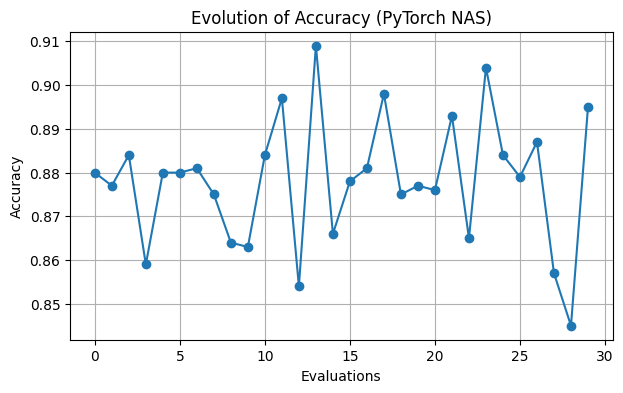

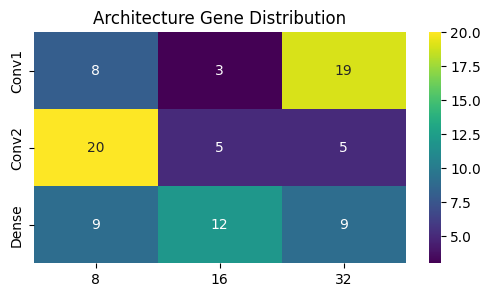

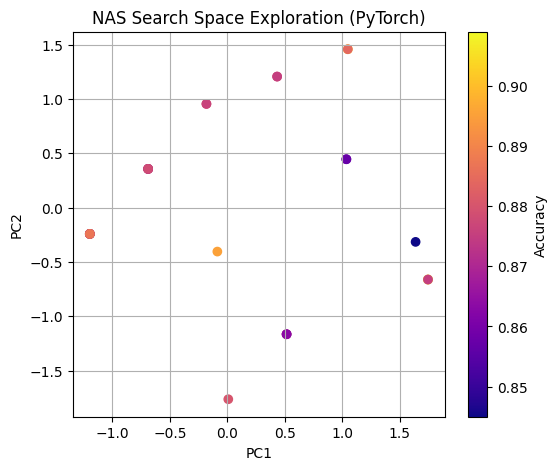

In [11]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# DATA (MNIST - reduced for speed)
# =========================================================
transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# subset for speed
x_train = torch.stack([train_data[i][0] for i in range(5000)])
y_train = torch.tensor([train_data[i][1] for i in range(5000)])

x_test = torch.stack([test_data[i][0] for i in range(1000)])
y_test = torch.tensor([test_data[i][1] for i in range(1000)])

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=64, shuffle=False)

# =========================================================
# SEARCH SPACE
# =========================================================
CONV_FILTERS = [8, 16, 32]
DENSE_UNITS = [32, 64, 128]

POP_SIZE = 6
GENERATIONS = 5
EPOCHS = 2

# =========================================================
# MODEL BUILDER (PyTorch)
# =========================================================
class Net(nn.Module):
    def __init__(self, f1, f2, dense):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, f1, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(f1, f2, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(
            nn.Linear(self._get_flat_dim(f1, f2), dense),
            nn.ReLU(),
            nn.Linear(dense, 10)
        )

    def _get_flat_dim(self, f1, f2):
        with torch.no_grad():
            x = torch.zeros(1, 1, 28, 28)
            x = nn.Conv2d(1, f1, 3)(x)
            x = nn.ReLU()(x)
            x = nn.MaxPool2d(2)(x)

            x = nn.Conv2d(f1, f2, 3)(x)
            x = nn.ReLU()(x)
            x = nn.MaxPool2d(2)(x)

            return x.numel()

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

# =========================================================
# FITNESS FUNCTION
# =========================================================
def fitness(genome):
    f1, f2, dense = genome

    model = Net(f1, f2, dense).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    for _ in range(EPOCHS):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

    # evaluation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            preds = torch.argmax(out, dim=1)

            correct += (preds == yb).sum().item()
            total += yb.size(0)

    return correct / total

# =========================================================
# GENOME
# =========================================================
def random_genome():
    return (
        random.choice(CONV_FILTERS),
        random.choice(CONV_FILTERS),
        random.choice(DENSE_UNITS)
    )

# =========================================================
# EVOLUTION OPERATORS
# =========================================================
def crossover(a, b):
    return tuple(random.choice([x, y]) for x, y in zip(a, b))

def mutate(g):
    g = list(g)

    if random.random() < 0.5:
        g[0] = random.choice(CONV_FILTERS)
    if random.random() < 0.5:
        g[1] = random.choice(CONV_FILTERS)
    if random.random() < 0.5:
        g[2] = random.choice(DENSE_UNITS)

    return tuple(g)

# =========================================================
# INITIAL POPULATION
# =========================================================
population = [random_genome() for _ in range(POP_SIZE)]

history = []

best = None
best_acc = 0

# =========================================================
# EVOLUTION LOOP
# =========================================================
for gen in range(GENERATIONS):

    print(f"\nGeneration {gen}")

    scored = []

    for g in population:
        acc = fitness(g)
        scored.append((acc, g))

        print(f"  {g} -> acc={acc:.4f}")

        history.append((gen, acc, g))

        if acc > best_acc:
            best_acc = acc
            best = g

    scored.sort(reverse=True, key=lambda x: x[0])

    population = [g for _, g in scored[:POP_SIZE // 2]]

    while len(population) < POP_SIZE:
        p1, p2 = random.sample(population, 2)
        population.append(mutate(crossover(p1, p2)))

# =========================================================
# RESULTS
# =========================================================
print("\nBEST ARCHITECTURE:", best)
print("BEST ACCURACY:", best_acc)

# =========================================================
# VISUALIZATION 1: Accuracy Curve
# =========================================================
gens = [h[0] for h in history]
accs = [h[1] for h in history]

plt.figure(figsize=(7,4))
plt.plot(accs, marker='o')
plt.title("Evolution of Accuracy (PyTorch NAS)")
plt.xlabel("Evaluations")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

# =========================================================
# VISUALIZATION 2: Architecture Heatmap
# =========================================================
filters1 = [h[2][0] for h in history]
filters2 = [h[2][1] for h in history]
dense = [h[2][2] for h in history]

data = np.zeros((3, 3))

for f in filters1:
    data[0, CONV_FILTERS.index(f)] += 1

for f in filters2:
    data[1, CONV_FILTERS.index(f)] += 1

for d in dense:
    data[2, DENSE_UNITS.index(d)] += 1

plt.figure(figsize=(6,3))
sns.heatmap(
    data,
    annot=True,
    cmap="viridis",
    xticklabels=CONV_FILTERS,
    yticklabels=["Conv1", "Conv2", "Dense"]
)
plt.title("Architecture Gene Distribution")
plt.show()

# =========================================================
# VISUALIZATION 3: PCA Search Trajectory
# =========================================================
X = np.array([
    [
        CONV_FILTERS.index(h[2][0]),
        CONV_FILTERS.index(h[2][1]),
        DENSE_UNITS.index(h[2][2])
    ]
    for h in history
])

pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(X2[:,0], X2[:,1], c=accs, cmap='plasma')
plt.colorbar(label='Accuracy')
plt.title("NAS Search Space Exploration (PyTorch)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()